# Flight EDA - Preprocessing & Feature Engineering Review

This notebook audits flight Silver Layer 2 and Gold feature-engineering outputs for delay-propagation modeling. It focuses on row lineage, audit decisions, time semantics, missing links, aircraft swaps, runway/route patterns, and feature quality.

In [10]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT_ROOT = next((p for p in candidates if (p / "18_24520617_24520636_Data").exists()), Path.cwd().resolve())

SILVER = PROJECT_ROOT / "18_24520617_24520636_Data" / "Silver_layer"

def has_complete_flight_silver(layer_path):
    checks = []
    for mode_dir, mode_name in [("Arrival", "arrival"), ("Departure", "departure")]:
        for airport in ["SGN", "HAN", "DAD"]:
            checks.append((layer_path / mode_dir / f"{airport.lower()}_flights_{mode_name}_silver_layer.csv").exists())
    return all(checks)

BRONZE = PROJECT_ROOT / "18_24520617_24520636_Data" / "Bronze_layer"
GOLD = PROJECT_ROOT / "18_24520617_24520636_Data" / "Gold_layer"
REPORT_DIR = SILVER / "Audit" / "flight_eda_reports"
FIG_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

AIRPORTS = ["SGN", "HAN", "DAD"]
MODES = ["arrival", "departure"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ACTIVE_SILVER_LAYER:", SILVER)
print("GOLD:", GOLD)
print("REPORT_DIR:", REPORT_DIR)

def show(title):
    display(Markdown(f"### {title}"))

def save_table(df, name, index=False, max_rows=30):
    path = REPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=index, encoding="utf-8-sig")
    print("saved", path)
    display(df.head(max_rows))
    return df

def save_fig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved", path)


PROJECT_ROOT: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay
ACTIVE_SILVER_LAYER: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer
GOLD: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Gold_layer
REPORT_DIR: /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports


## 1. Load flight, audit, and feature outputs

The notebook reads Silver_layer_2 as the active preprocessed flight layer. Gold outputs are kept in the existing Gold_layer path.

In [11]:
def read_csv(path, **kwargs):
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path, low_memory=False, **kwargs)

silver = {"arrival": {}, "departure": {}}
bronze = {"arrival": {}, "departure": {}}
gold = {"arrival": {}, "departure": {}}

for airport in AIRPORTS:
    low = airport.lower()
    silver["arrival"][airport] = read_csv(SILVER / "Arrival" / f"{low}_flights_arrival_silver_layer.csv")
    silver["departure"][airport] = read_csv(SILVER / "Departure" / f"{low}_flights_departure_silver_layer.csv")
    bronze["arrival"][airport] = read_csv(BRONZE / "Arrival" / f"{low}_flights_arrival_bronze_layer.csv")
    bronze["departure"][airport] = read_csv(BRONZE / "Departure" / f"{low}_flights_departure_bronze_layer.csv")
    gold["arrival"][airport] = read_csv(GOLD / "Arrival" / f"{low}_flights_arrival_gold_layer.csv")
    gold["departure"][airport] = read_csv(GOLD / "Departure" / f"{low}_flights_departure_gold_layer.csv")

audit = {
    "summary": read_csv(SILVER / "Audit" / "audit_summary.csv"),
    "time_semantics": read_csv(SILVER / "Audit" / "audit_arrival_time_semantics.csv"),
    "dedup": read_csv(SILVER / "Audit" / "audit_deduplicate_decisions.csv"),
    "same_origin": read_csv(SILVER / "Audit" / "audit_same_origin_actions.csv"),
    "dep_without_arr": read_csv(SILVER / "Audit" / "audit_departure_without_arrival.csv"),
    "arr_without_dep": read_csv(SILVER / "Audit" / "audit_arrival_without_departure.csv"),
    "swap": read_csv(SILVER / "Audit" / "audit_aircraft_swap_matches.csv"),
}

gold_audit = {
    "leakage": read_csv(GOLD / "Audit" / "temporal_data_leakage_report.csv"),
    "imputation": read_csv(GOLD / "Audit" / "imputation_metrics_log.csv"),
    "feature_summary": read_csv(GOLD / "Audit" / "feature_summary_stats.csv"),
    "eligibility": read_csv(GOLD / "Audit" / "feature_eligibility_audit.csv"),
}
master = read_csv(GOLD / "Features" / "master_aero_features_gold.csv")

print("Loaded Silver files:")
for mode in MODES:
    for airport in AIRPORTS:
        print(mode, airport, silver[mode][airport].shape)
print("Master Gold:", master.shape)


Loaded Silver files:
arrival SGN (36699, 22)
arrival HAN (24899, 22)
arrival DAD (12573, 23)
departure SGN (36735, 22)
departure HAN (28502, 22)
departure DAD (12521, 27)
Master Gold: (0, 0)


## 2. Layer lineage and path consistency

This section checks whether Bronze -> Silver_layer_2 -> Gold outputs are present and whether per-airport Gold files preserve Silver row counts.

In [12]:
inventory_rows = []
for layer_name, layer_data in [("Bronze", bronze), ("Silver_layer", silver), ("Gold", gold)]:
    for mode in MODES:
        for airport, df in layer_data[mode].items():
            inventory_rows.append({
                "layer": layer_name,
                "mode": mode,
                "airport": airport,
                "rows": len(df),
                "columns": df.shape[1],
                "has_file": not df.empty,
            })
inventory = pd.DataFrame(inventory_rows)
save_table(inventory, "01_layer_file_inventory")

lineage = inventory.pivot_table(index=["airport", "mode"], columns="layer", values="rows", aggfunc="first").reset_index()
for col in ["Bronze", "Silver_layer", "Gold"]:
    if col not in lineage.columns:
        lineage[col] = np.nan
lineage["bronze_to_silver_delta"] = lineage["Silver_layer"] - lineage["Bronze"]
lineage["silver_to_gold_delta"] = lineage["Gold"] - lineage["Silver_layer"]
save_table(lineage, "02_row_lineage")

print("Gold per-airport no-drop check:")
display(lineage[["airport", "mode", "Silver_layer", "Gold", "silver_to_gold_delta"]])


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/01_layer_file_inventory.csv


,layer,mode,airport,rows,columns,has_file
0,Bronze,arrival,SGN,36721,12,True
1,Bronze,arrival,HAN,24921,12,True
2,Bronze,arrival,DAD,12575,14,True
3,Bronze,departure,SGN,36789,14,True
4,Bronze,departure,HAN,28503,14,True
5,Bronze,departure,DAD,12529,17,True
6,Silver_layer,arrival,SGN,36699,22,True
7,Silver_layer,arrival,HAN,24899,22,True
8,Silver_layer,arrival,DAD,12573,23,True
9,Silver_layer,departure,SGN,36735,22,True


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/02_row_lineage.csv


layer,airport,mode,Bronze,Gold,Silver_layer,bronze_to_silver_delta,silver_to_gold_delta
0,DAD,arrival,12575,12573,12573,-2,0
1,DAD,departure,12529,12521,12521,-8,0
2,HAN,arrival,24921,24899,24899,-22,0
3,HAN,departure,28503,28502,28502,-1,0
4,SGN,arrival,36721,36699,36699,-22,0
5,SGN,departure,36789,36735,36735,-54,0


Gold per-airport no-drop check:


layer,airport,mode,Silver_layer,Gold,silver_to_gold_delta
0,DAD,arrival,12573,12573,0
1,DAD,departure,12521,12521,0
2,HAN,arrival,24899,24899,0
3,HAN,departure,28502,28502,0
4,SGN,arrival,36699,36699,0
5,SGN,departure,36735,36735,0


## 3. Preprocessing audit review

This section converts preprocessing audit files into operational checks: deduplication, source-specific arrival time semantics, same-origin anomalies, missing links, and aircraft swap matching.

In [13]:
if not audit["summary"].empty:
    summary = audit["summary"].copy()
    save_table(summary, "03_audit_summary_raw", max_rows=40)
    key_metrics = summary[summary["Metric"].isin([
        "rows_input", "rows_after_basic_clean", "rows_output",
        "cluster_duplicate_removed", "same_day_60m_duplicate_removed",
        "same_origin_rows", "same_origin_return_matched", "same_origin_dropped",
        "arrival_without_departure_rows", "departure_without_arrival_rows",
        "missing_departure_marked_total", "missing_arrival_marked_total",
    ])].copy()
    save_table(key_metrics, "04_audit_summary_key_metrics", max_rows=80)
else:
    print("Missing audit_summary.csv")

if not audit["time_semantics"].empty:
    time_sem = audit["time_semantics"].copy()
    time_sem["actual_landing_parse_rate_pct"] = time_sem["rows_actual_landing_parsed"] / time_sem["rows_total_arrival"] * 100
    save_table(time_sem, "05_arrival_time_semantics")

if not audit["dedup"].empty:
    dedup_summary = (audit["dedup"].groupby(["airport", "mode", "dedup_reason"], dropna=False)
                     .agg(rows_dropped=("row_index_dropped", "count"), max_gap_min=("actual_time_gap_minutes", "max"), median_gap_min=("actual_time_gap_minutes", "median"))
                     .reset_index())
    save_table(dedup_summary, "06_dedup_summary")

missing_link_rows = []
for name, df in [("departure_without_arrival", audit["dep_without_arr"]), ("arrival_without_departure", audit["arr_without_dep"]), ("same_origin", audit["same_origin"] )]:
    if df.empty:
        missing_link_rows.append({"audit": name, "rows": 0})
    else:
        row = {"audit": name, "rows": len(df)}
        for col in ["airport", "Airport", "Action", "Drop_Reason", "Match_Status"]:
            if col in df.columns:
                row[f"unique_{col}"] = df[col].nunique(dropna=True)
        missing_link_rows.append(row)
save_table(pd.DataFrame(missing_link_rows), "07_missing_link_and_same_origin_summary")

if not audit["swap"].empty:
    swap = audit["swap"].copy()
    swap_summary = swap.groupby("Route", dropna=False).agg(
        matched_pairs=("Route", "size"),
        swap_rate_pct=("Is_Aircraft_Swapped", lambda s: s.astype(bool).mean() * 100),
        median_gap_h=("Gap_Hours", "median"),
        p95_gap_h=("Gap_Hours", lambda s: s.quantile(0.95)),
    ).reset_index()
    save_table(swap_summary, "08_aircraft_swap_summary")


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/03_audit_summary_raw.csv


,Airport,Mode,Metric,Value
0,SGN,departure,rows_input,36789
1,SGN,departure,same_origin_rows_restored_from_prior_audit,0
2,SGN,departure,rows_after_basic_clean,36789
3,SGN,departure,header_rows_removed,0
4,SGN,departure,invalid_iata_fixed,1
5,SGN,departure,invalid_runway_fixed,0
6,SGN,departure,exact_duplicate_removed,0
7,SGN,departure,cluster_duplicate_removed,54
8,SGN,departure,same_day_60m_duplicate_removed,54
9,SGN,departure,dual_runway_duplicate_removed,0


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/04_audit_summary_key_metrics.csv


,Airport,Mode,Metric,Value
0,SGN,departure,rows_input,36789
2,SGN,departure,rows_after_basic_clean,36789
7,SGN,departure,cluster_duplicate_removed,54
8,SGN,departure,same_day_60m_duplicate_removed,54
18,SGN,arrival,rows_input,36721
20,SGN,arrival,rows_after_basic_clean,36721
25,SGN,arrival,cluster_duplicate_removed,1
26,SGN,arrival,same_day_60m_duplicate_removed,1
36,HAN,departure,rows_input,28503
38,HAN,departure,rows_after_basic_clean,28503


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/05_arrival_time_semantics.csv


...

,airport,mode,dedup_reason,rows_dropped,max_gap_min,median_gap_min
0,DAD,arrival,same_day_150m_window,2,60.0,30.0
1,DAD,departure,same_day_150m_window,8,75.0,20.0
2,HAN,arrival,same_day_150m_window,5,72.0,0.0
3,HAN,departure,same_day_150m_window,1,39.0,39.0
4,SGN,arrival,same_day_150m_window,1,66.0,66.0
5,SGN,departure,same_day_150m_window,54,122.0,0.5


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/07_missing_link_and_same_origin_summary.csv


,audit,rows,unique_Action,unique_Drop_Reason,unique_Airport
0,departure_without_arrival,619,1,0.0,NaN
1,arrival_without_departure,476,1,0.0,NaN
2,same_origin,84,3,NaN,2.0


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/08_aircraft_swap_summary.csv


,Route,matched_pairs,swap_rate_pct,median_gap_h,p95_gap_h
0,DAD->HAN,2219,0.0,1.3500,1.80167
1,DAD->SGN,3271,0.0,1.4667,2.06670
2,HAN->DAD,2364,0.0,1.1000,1.23330
3,HAN->SGN,6559,0.0,1.7833,2.20000
4,SGN->DAD,3177,0.0,1.0333,1.20000
5,SGN->HAN,6528,0.0,1.7167,1.91670


## 4. Schema, missingness, route, and runway EDA

This section checks which fields are airport-specific, which fields are missing, and how routes/runways are distributed.

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/09_missingness_by_file.csv


,mode,airport,column,missing_count,missing_rate_pct,nunique
13,arrival,SGN,Scheduled_Time,36699,100.000000,0
35,arrival,HAN,Scheduled_Time,24899,100.000000,0
58,arrival,DAD,Arrival_Flight_Duration_Minutes,12573,100.000000,0
61,arrival,DAD,Same_Origin_Action,12573,100.000000,0
38,arrival,HAN,Same_Origin_Action,24892,99.971886,2
16,arrival,SGN,Same_Origin_Action,36660,99.893730,2
81,departure,SGN,Matched_Actual_Tail,27041,73.610998,218
82,departure,SGN,Swap_Match_Gap_Minutes,27030,73.581053,125
103,departure,HAN,Matched_Actual_Tail,19589,68.728510,227
104,departure,HAN,Swap_Match_Gap_Minutes,19579,68.693425,129


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/10_schema_presence_by_airport.csv


,mode,column,SGN,HAN,DAD
0,arrival,Actual_Tail,True,True,True
1,arrival,Actual_Time,True,True,True
2,arrival,Aircraft_Type,True,True,True
3,arrival,Airline,True,True,True
4,arrival,Arrival_Flight_Duration_Minutes,True,True,True
5,arrival,Arrival_Runway,True,True,True
6,arrival,Belt,False,False,True
7,arrival,Category,True,True,True
8,arrival,Crawl_Date,True,True,True
9,arrival,Data_Completeness,True,True,True


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/11_top_departure_routes.csv


,origin_airport,dest_iata,departure_rows
0,SGN,HAN,6676
1,SGN,DAD,3195
2,SGN,PQC,1966
3,SGN,VII,1337
4,SGN,VCS,1296
5,SGN,HPH,1231
6,SGN,HUI,1198
7,SGN,THD,1100
8,SGN,SIN,1070
9,SGN,BKK,956


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/12_runway_distribution.csv


,mode,airport,runway,rows,rate_pct
0,arrival,SGN,25R,36111,98.397777
1,arrival,SGN,25L,416,1.133546
2,arrival,SGN,07L,168,0.457778
3,arrival,SGN,07R,4,0.010899
4,arrival,HAN,11L,23850,95.786979
5,arrival,HAN,29R,624,2.506125
6,arrival,HAN,11R,411,1.650669
7,arrival,HAN,29L,14,0.056227
8,arrival,DAD,35L,12018,95.585779
9,arrival,DAD,35R,519,4.127893


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/12_runway_distribution_heatmap.png


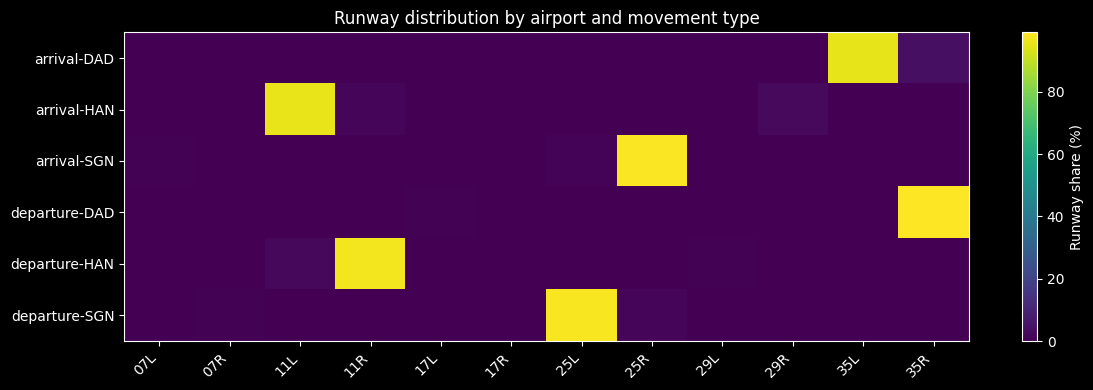

In [14]:
missing_rows = []
for mode in MODES:
    for airport, df in silver[mode].items():
        for col in df.columns:
            missing_rows.append({
                "mode": mode,
                "airport": airport,
                "column": col,
                "missing_count": int(df[col].isna().sum()),
                "missing_rate_pct": float(df[col].isna().mean() * 100),
                "nunique": int(df[col].nunique(dropna=True)),
            })
missing = pd.DataFrame(missing_rows).sort_values(["missing_rate_pct", "missing_count"], ascending=False)
save_table(missing, "09_missingness_by_file", max_rows=80)

schema_rows = []
for mode in MODES:
    all_cols = sorted(set().union(*[set(df.columns) for df in silver[mode].values()]))
    for col in all_cols:
        schema_rows.append({"mode": mode, "column": col, **{airport: col in silver[mode][airport].columns for airport in AIRPORTS}})
schema = pd.DataFrame(schema_rows)
save_table(schema, "10_schema_presence_by_airport", max_rows=120)

route_rows = []
for airport, df in silver["departure"].items():
    if "IATA" in df.columns:
        vc = df["IATA"].fillna("N/A").value_counts().head(15)
        for dest_iata, rows in vc.items():
            route_rows.append({"origin_airport": airport, "dest_iata": dest_iata, "departure_rows": int(rows)})
route_volume = pd.DataFrame(route_rows)
save_table(route_volume, "11_top_departure_routes", max_rows=60)

runway_rows = []
for mode, runway_col in [("arrival", "Arrival_Runway"), ("departure", "Departure_Runway")]:
    for airport, df in silver[mode].items():
        if runway_col not in df.columns:
            continue
        vc = df[runway_col].fillna("N/A").value_counts(dropna=False).head(12)
        total = len(df)
        for runway, rows in vc.items():
            runway_rows.append({"mode": mode, "airport": airport, "runway": runway, "rows": int(rows), "rate_pct": rows / total * 100})
runway_dist = pd.DataFrame(runway_rows)
save_table(runway_dist, "12_runway_distribution", max_rows=80)

if not runway_dist.empty:
    pivot = runway_dist.pivot_table(index=["mode", "airport"], columns="runway", values="rate_pct", fill_value=0)
    plt.figure(figsize=(12, max(4, 0.35 * len(pivot))))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label="Runway share (%)")
    plt.yticks(range(len(pivot.index)), [f"{m}-{a}" for m,a in pivot.index])
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.title("Runway distribution by airport and movement type")
    save_fig("12_runway_distribution_heatmap.png")
    plt.show()


## 5. Temporal and traffic pattern EDA

This section audits daily/hourly flight density, because delay propagation depends on exposure and congestion, not only single-flight quality.

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/13_daily_flight_volume.csv


,airport,mode,date,flights
0,DAD,arrival,2025-12-15,1
1,DAD,arrival,2025-12-16,116
2,DAD,arrival,2025-12-17,121
3,DAD,arrival,2025-12-18,127
4,DAD,arrival,2025-12-19,124
5,DAD,arrival,2025-12-20,127
6,DAD,arrival,2025-12-21,134
7,DAD,arrival,2025-12-22,133
8,DAD,arrival,2025-12-23,129
9,DAD,arrival,2025-12-24,134


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/14_hourly_flight_volume.csv


,airport,mode,hour,flights
0,DAD,arrival,0.0,704
1,DAD,arrival,1.0,359
2,DAD,arrival,2.0,88
3,DAD,arrival,3.0,61
4,DAD,arrival,4.0,77
5,DAD,arrival,5.0,47
6,DAD,arrival,6.0,77
7,DAD,arrival,7.0,494
8,DAD,arrival,8.0,283
9,DAD,arrival,9.0,677


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/14_hourly_flight_exposure_heatmap.png


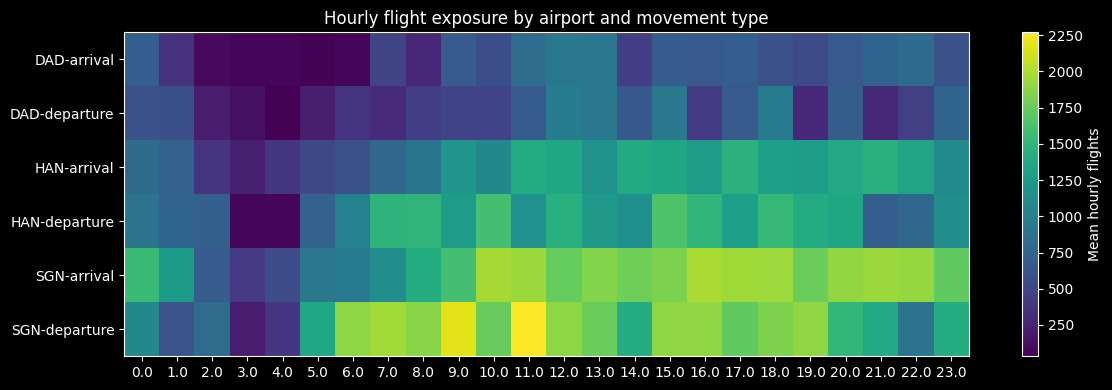

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/15_category_distribution.csv


,airport,mode,Category,rows
0,DAD,arrival,general aviation,1075
1,DAD,arrival,passenger,11498
2,DAD,departure,business jet,1
3,DAD,departure,general aviation,776
4,DAD,departure,passenger,11739
5,DAD,departure,NaN,5
6,HAN,arrival,business jet,94
7,HAN,arrival,cargo,1360
8,HAN,arrival,general aviation,812
9,HAN,arrival,helicopter,1


,airport,mode,Category,rows
0,DAD,arrival,general aviation,1075
1,DAD,arrival,passenger,11498
2,DAD,departure,business jet,1
3,DAD,departure,general aviation,776
4,DAD,departure,passenger,11739
5,DAD,departure,NaN,5
6,HAN,arrival,business jet,94
7,HAN,arrival,cargo,1360
8,HAN,arrival,general aviation,812
9,HAN,arrival,helicopter,1


In [15]:
def parse_time(df, mode):
    out = df.copy()
    ref_col = "Actual_Time" if mode == "arrival" else "Scheduled_Time"
    if ref_col in out.columns:
        out["Event_Time"] = pd.to_datetime(out[ref_col], errors="coerce")
    else:
        out["Event_Time"] = pd.NaT
    return out

temporal_frames = []
for mode in MODES:
    for airport, df in silver[mode].items():
        tmp = parse_time(df, mode)
        tmp["mode"] = mode
        tmp["airport"] = airport
        temporal_frames.append(tmp[["mode", "airport", "Event_Time", "Flight_No", "Airline", "Category"] if "Category" in tmp.columns else ["mode", "airport", "Event_Time", "Flight_No", "Airline"]])
temporal = pd.concat(temporal_frames, ignore_index=True, sort=False)
temporal["date"] = temporal["Event_Time"].dt.date
temporal["hour"] = temporal["Event_Time"].dt.hour

daily = temporal.groupby(["airport", "mode", "date"], dropna=False).size().rename("flights").reset_index()
hourly = temporal.groupby(["airport", "mode", "hour"], dropna=False).size().rename("flights").reset_index()
save_table(daily, "13_daily_flight_volume", max_rows=80)
save_table(hourly, "14_hourly_flight_volume", max_rows=80)

hour_pivot = hourly.pivot_table(index=["airport", "mode"], columns="hour", values="flights", aggfunc="mean", fill_value=0)
plt.figure(figsize=(12, max(4, 0.5 * len(hour_pivot))))
plt.imshow(hour_pivot.values, aspect="auto")
plt.colorbar(label="Mean hourly flights")
plt.yticks(range(len(hour_pivot.index)), [f"{a}-{m}" for a,m in hour_pivot.index])
plt.xticks(range(len(hour_pivot.columns)), hour_pivot.columns)
plt.title("Hourly flight exposure by airport and movement type")
save_fig("14_hourly_flight_exposure_heatmap.png")
plt.show()

category = temporal.groupby(["airport", "mode", "Category"], dropna=False).size().rename("rows").reset_index()
save_table(category, "15_category_distribution", max_rows=80)


## 6. Gold feature engineering EDA

This section reviews the generated features, audit files, no-drop behavior of per-airport Gold files, and the curated master feature table.

In [16]:
gold_lineage = lineage[["airport", "mode", "Silver_layer", "Gold", "silver_to_gold_delta"]].copy()
save_table(gold_lineage, "16_gold_no_drop_check")

if not master.empty:
    master_overview = pd.DataFrame({
        "metric": ["rows", "columns", "record_types", "flight_no_missing_rate_pct", "imputed_link_rate_pct", "congested_rate_pct"],
        "value": [
            len(master),
            master.shape[1],
            master["Record_Type"].nunique(dropna=True) if "Record_Type" in master.columns else np.nan,
            master["Flight_No"].isna().mean() * 100 if "Flight_No" in master.columns else np.nan,
            pd.to_numeric(master.get("Is_Imputed_Link", pd.Series(dtype=float)), errors="coerce").fillna(0).mean() * 100 if "Is_Imputed_Link" in master.columns else np.nan,
            pd.to_numeric(master.get("Is_Airport_Congested", pd.Series(dtype=float)), errors="coerce").fillna(0).mean() * 100 if "Is_Airport_Congested" in master.columns else np.nan,
        ],
    })
    save_table(master_overview, "17_master_feature_overview")

    numeric_cols = master.select_dtypes(include=[np.number]).columns.tolist()
    feature_quality = []
    for col in numeric_cols:
        s = master[col]
        feature_quality.append({
            "feature": col,
            "missing_rate_pct": s.isna().mean() * 100,
            "zero_rate_pct": (s.fillna(0) == 0).mean() * 100,
            "nunique": s.nunique(dropna=True),
            "mean": s.mean(),
            "p95": s.quantile(0.95),
            "max": s.max(),
        })
    feature_quality = pd.DataFrame(feature_quality).sort_values(["missing_rate_pct", "nunique"], ascending=[False, True])
    save_table(feature_quality, "18_master_feature_quality", max_rows=80)

    delay_cols = [c for c in ["Departure_Delay", "Arrival_Delay", "Accumulated_Delay", "Turnaround_Buffer", "Airport_Load_Factor", "Number_of_Flights_in_Last_Hour"] if c in master.columns]
    if delay_cols:
        delay_summary = master[delay_cols].describe(percentiles=[.05,.25,.5,.75,.95]).T.reset_index().rename(columns={"index":"feature"})
        save_table(delay_summary, "19_delay_and_load_distribution", max_rows=40)

for name, df in gold_audit.items():
    if df.empty:
        print("missing or empty gold audit", name)
    else:
        save_table(df, f"20_gold_audit_{name}", max_rows=80)


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/16_gold_no_drop_check.csv


layer,airport,mode,Silver_layer,Gold,silver_to_gold_delta
0,DAD,arrival,12573,12573,0
1,DAD,departure,12521,12521,0
2,HAN,arrival,24899,24899,0
3,HAN,departure,28502,28502,0
4,SGN,arrival,36699,36699,0
5,SGN,departure,36735,36735,0


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/20_gold_audit_leakage.csv


,check_name,violation_count,rows_checked,status
0,departure_scheduled_after_previous_arrival,0,74723,pass


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/20_gold_audit_imputation.csv


,Record_Type,Missing_Link_Type,rows,imputed_links,audit_missing_expected
0,Arrival,arrival_without_departure,472,472,1095
1,Arrival,NaN,73324,0,1095
2,Departure,departure_without_arrival,619,619,1095
3,Departure,NaN,74104,432,1095


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/20_gold_audit_feature_summary.csv


,feature,missing_rate,mean,std,min,p50,p95,max
0,Terminal,0.002363,1.730650,0.810463,0.00,2.000000,3.000000,3.000000
1,Arrival_Flight_Duration_Minutes,0.599943,138.986519,110.152138,8.00,103.000000,356.000000,998.000000
2,Source_Row_Index,0.000000,14653.955480,9849.958750,0.00,12743.000000,32956.000000,36734.000000
3,Belt,0.918839,2.803965,1.295979,1.00,3.000000,5.000000,5.000000
4,Arrival_Delay_This_Leg,0.503121,2.507453,17.456723,-685.00,0.000000,19.000000,625.000000
5,Is_Imputed_Link,0.000000,0.010255,0.100745,0.00,0.000000,0.000000,1.000000
6,Median_Turnaround_Time,0.503121,63.622893,11.395856,35.00,60.000000,90.000000,90.000000
7,Tail_Sequence_Day,0.000000,2.169103,1.434385,1.00,2.000000,5.000000,10.000000
8,Is_First_Flight,0.000000,0.468371,0.499000,0.00,0.000000,1.000000,1.000000
9,Arrival_Delay,0.000000,2.022280,15.721087,-685.00,0.000000,15.000000,625.000000


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/20_gold_audit_eligibility.csv


,mode,rows_input_after_silver,rows_feature_eligible,rows_excluded_from_master,reason
0,arrival,74125,73796,329,missing Actual_Time or Tail_Number prevents ta...
1,departure,77695,74723,2972,missing Scheduled_Time/Event_Time or Tail_Numb...


## 6.1. Visual diagnostics for flight preprocessing and feature engineering

Ph?n n?y b? sung tr?c quan ?? nh?n nhanh c?c v?n ?? v?n h?nh v? ch?t l??ng d? li?u: row lineage, audit issue size, traffic peak, runway dominance, route concentration, category mix, v? outlier trong delay/turnaround/load features. C?c bi?u ?? ???c l?u ? `Data crawl/Silver_layer_2/Audit/flight_eda_reports/figures/`.


### 6.1. Visual diagnostics for flight EDA

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/21_row_lineage_by_airport_mode.png


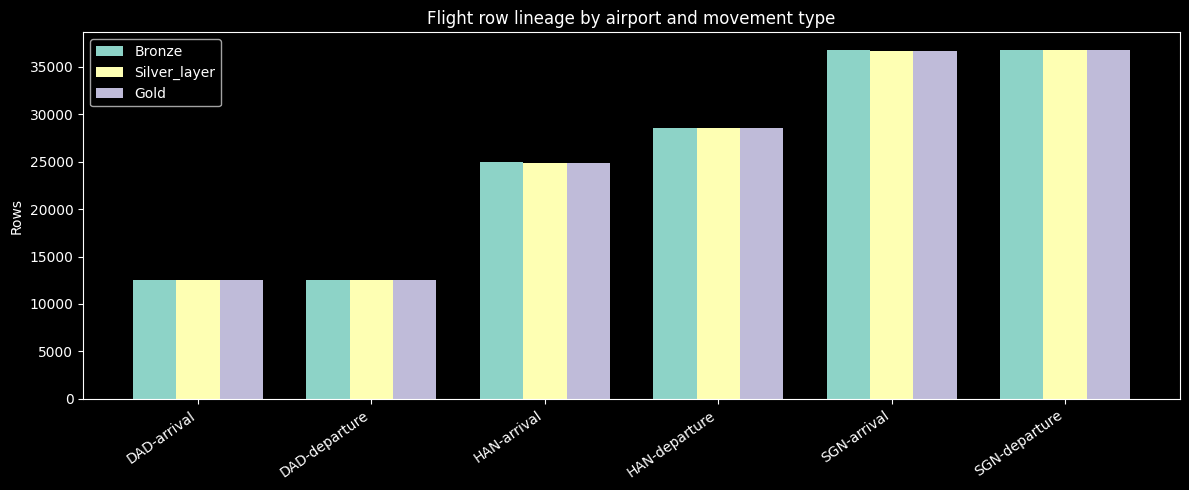

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/21_bronze_to_silver_delta.png


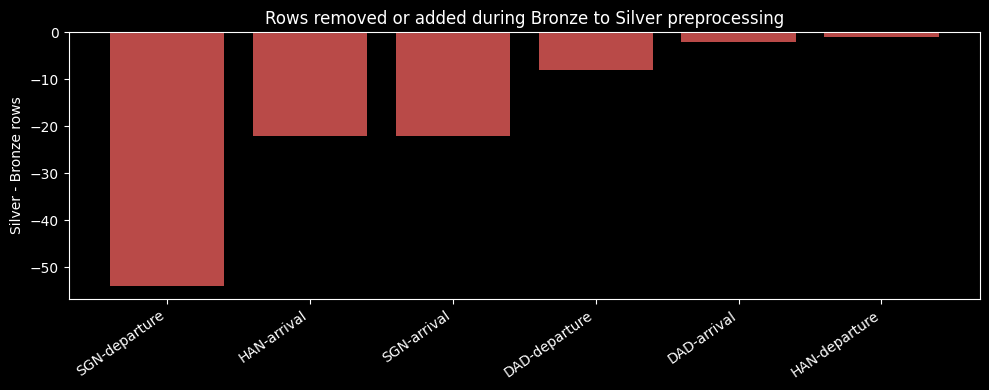

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/21_visual_issue_summary.csv


,issue,rows,stage
5,master_excluded_departure,2972,Gold feature eligibility
1,departure_without_arrival,619,Silver link audit
2,arrival_without_departure,476,Silver link audit
4,master_excluded_arrival,329,Gold feature eligibility
3,same_origin_actions,84,Silver link audit
0,dedup_rows_dropped,71,Silver preprocessing


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/21_issue_size_dashboard.png


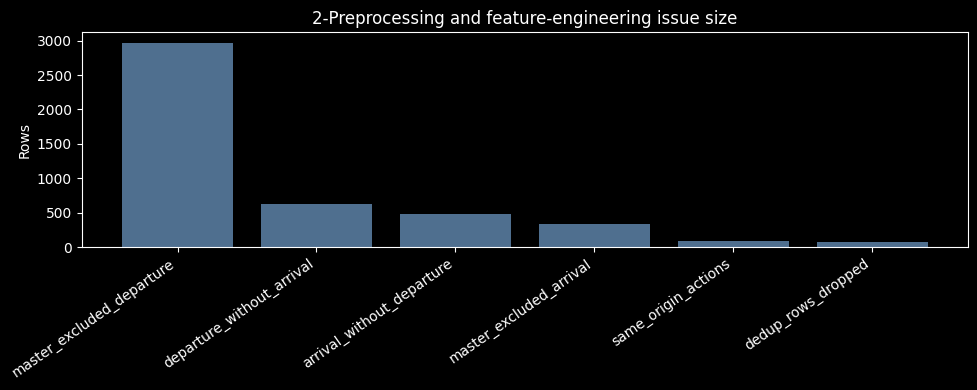

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/22_daily_flight_volume_lines.png


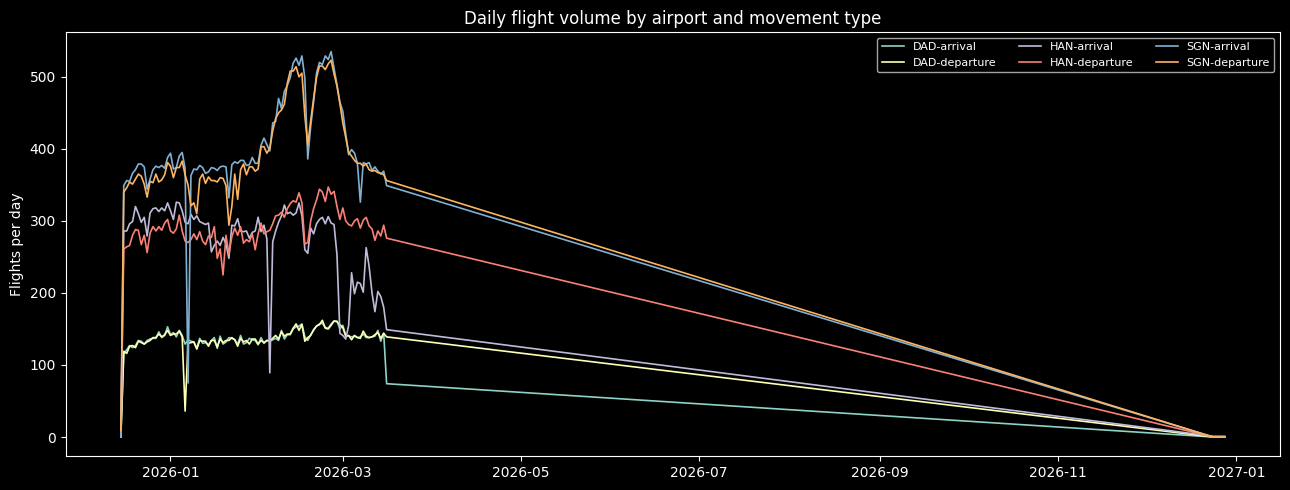

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/22_hourly_peak_summary.csv


,airport,mode,hour,flights
12,DAD,arrival,12.0,932
13,DAD,arrival,13.0,911
11,DAD,arrival,11.0,835
36,DAD,departure,12.0,972
42,DAD,departure,18.0,949
39,DAD,departure,15.0,929
65,HAN,arrival,17.0,1471
69,HAN,arrival,21.0,1439
59,HAN,arrival,11.0,1406
96,HAN,departure,NaN,1992


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/22_hourly_traffic_profile.png


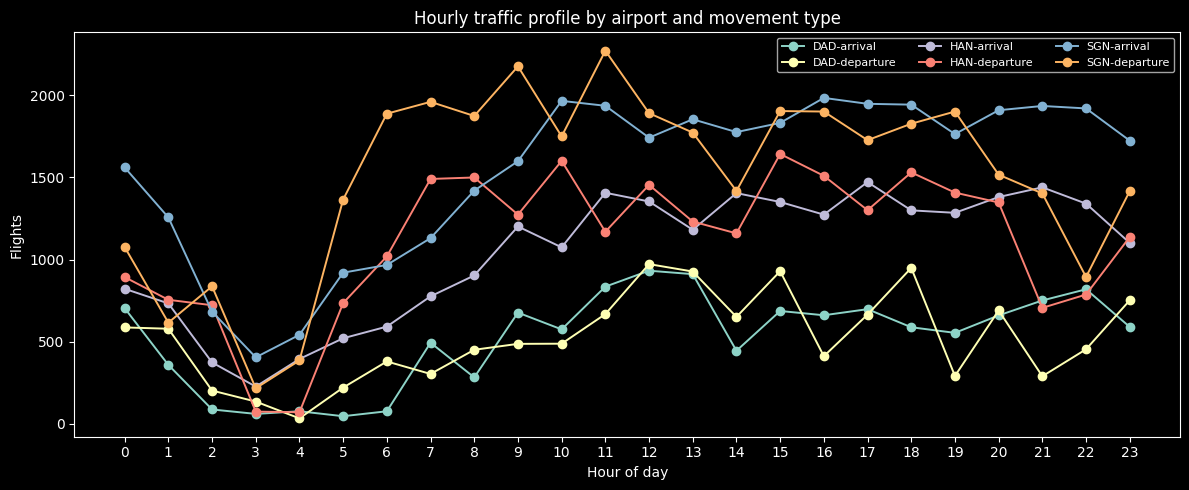

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/23_runway_dominance_summary.csv


,mode,airport,runway,rows,rate_pct
20,departure,DAD,35R,12409,99.105503
0,arrival,SGN,25R,36111,98.397777
12,departure,SGN,25L,36105,98.285014
16,departure,HAN,11R,27805,97.554558
4,arrival,HAN,11L,23850,95.786979
8,arrival,DAD,35L,12018,95.585779


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/23_runway_dominance.png


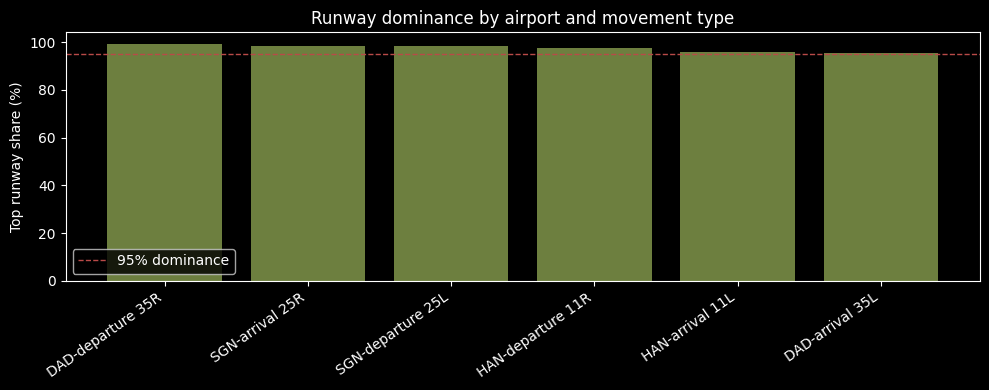

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/23_route_concentration_summary.csv


,origin_airport,top15_rows,top3_rows,top3_share_within_top15_pct
0,DAD,11504,7191,62.508693
1,HAN,18786,10318,54.923879
2,SGN,24176,11837,48.961780


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/23_top_departure_routes.png


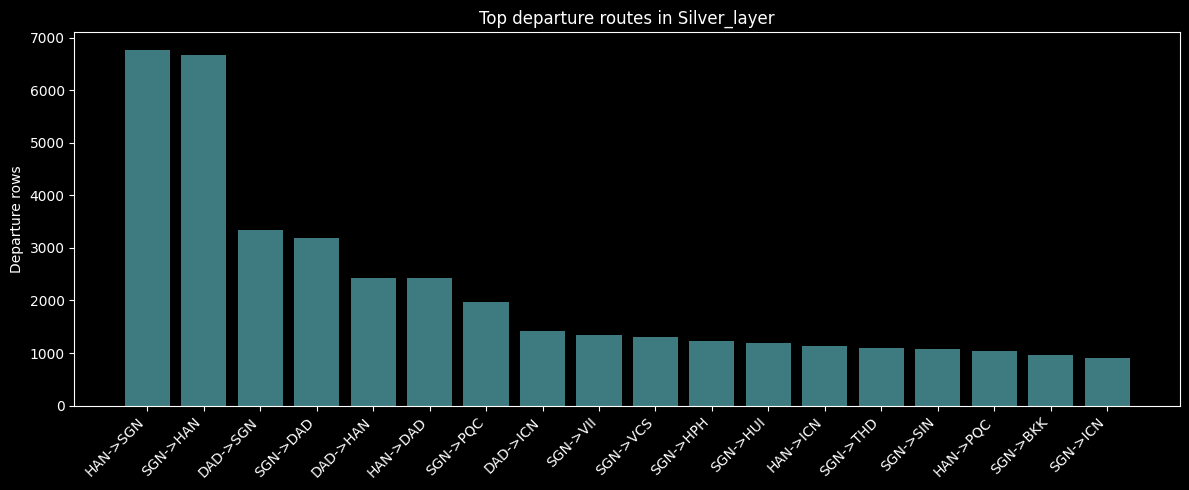

saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/24_category_mix_summary.csv


,airport,mode,category_group,rows,rate_pct
0,DAD,arrival,non_passenger_or_missing,1075,8.550068
1,DAD,arrival,passenger,11498,91.449932
2,DAD,departure,non_passenger_or_missing,782,6.245508
3,DAD,departure,passenger,11739,93.754492
4,HAN,arrival,non_passenger_or_missing,2273,9.128881
5,HAN,arrival,passenger,22626,90.871119
6,HAN,departure,non_passenger_or_missing,2639,9.258999
7,HAN,departure,passenger,25863,90.741001
8,SGN,arrival,non_passenger_or_missing,1350,3.678574
9,SGN,arrival,passenger,35349,96.321426


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/figures/24_category_mix_stacked.png


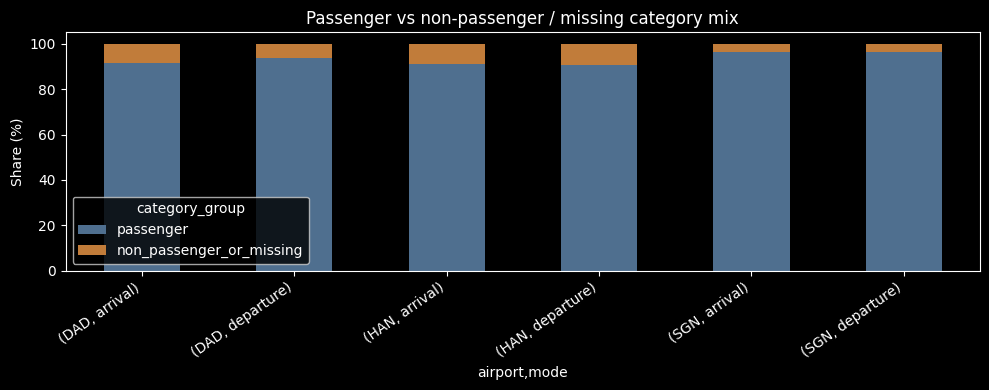

In [17]:
# =========================
# 6.1. Visual diagnostics
# =========================

show("6.1. Visual diagnostics for flight EDA")

# 1) Row lineage by airport-mode across layers.
if not lineage.empty:
    lineage_plot = lineage.copy()
    lineage_plot["airport_mode"] = lineage_plot["airport"] + "-" + lineage_plot["mode"]
    x = np.arange(len(lineage_plot))
    width = 0.25
    plt.figure(figsize=(12, 5))
    for offset, layer in [(-width, "Bronze"), (0, "Silver_layer"), (width, "Gold")]:
        plt.bar(x + offset, lineage_plot[layer], width=width, label=layer)
    plt.xticks(x, lineage_plot["airport_mode"], rotation=35, ha="right")
    plt.ylabel("Rows")
    plt.title("Flight row lineage by airport and movement type")
    plt.legend()
    save_fig("21_row_lineage_by_airport_mode.png")
    plt.show()

    delta_plot = lineage_plot.sort_values("bronze_to_silver_delta")
    colors = ["#b94a48" if v < 0 else "#2f7d4f" for v in delta_plot["bronze_to_silver_delta"]]
    plt.figure(figsize=(10, 4))
    plt.bar(delta_plot["airport_mode"], delta_plot["bronze_to_silver_delta"], color=colors)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Silver - Bronze rows")
    plt.title("Rows removed or added during Bronze to Silver preprocessing")
    plt.xticks(rotation=35, ha="right")
    save_fig("21_bronze_to_silver_delta.png")
    plt.show()

# 2) Issue-size dashboard from preprocessing and feature eligibility audits.
issue_rows = []
if not audit.get("dedup", pd.DataFrame()).empty:
    issue_rows.append({"issue": "dedup_rows_dropped", "rows": len(audit["dedup"]), "stage": "Silver preprocessing"})
if not audit.get("dep_without_arr", pd.DataFrame()).empty:
    issue_rows.append({"issue": "departure_without_arrival", "rows": len(audit["dep_without_arr"]), "stage": "Silver link audit"})
if not audit.get("arr_without_dep", pd.DataFrame()).empty:
    issue_rows.append({"issue": "arrival_without_departure", "rows": len(audit["arr_without_dep"]), "stage": "Silver link audit"})
if not audit.get("same_origin", pd.DataFrame()).empty:
    issue_rows.append({"issue": "same_origin_actions", "rows": len(audit["same_origin"]), "stage": "Silver link audit"})
if not gold_audit.get("eligibility", pd.DataFrame()).empty:
    for _, r in gold_audit["eligibility"].iterrows():
        issue_rows.append({"issue": f"master_excluded_{r['mode']}", "rows": int(r["rows_excluded_from_master"]), "stage": "Gold feature eligibility"})
issue_summary = pd.DataFrame(issue_rows).sort_values("rows", ascending=False)
if not issue_summary.empty:
    save_table(issue_summary, "21_visual_issue_summary", max_rows=20)
    plt.figure(figsize=(10, 4))
    plt.bar(issue_summary["issue"], issue_summary["rows"], color="#4f6f8f")
    plt.ylabel("Rows")
    plt.title("2-Preprocessing and feature-engineering issue size")
    plt.xticks(rotation=35, ha="right")
    save_fig("21_issue_size_dashboard.png")
    plt.show()

# 3) Daily and hourly traffic views.
if "daily" in globals() and not daily.empty:
    daily_pivot = daily.pivot_table(index="date", columns=["airport", "mode"], values="flights", aggfunc="sum").fillna(0)
    plt.figure(figsize=(13, 5))
    for col in daily_pivot.columns:
        plt.plot(pd.to_datetime(daily_pivot.index), daily_pivot[col], linewidth=1.2, label=f"{col[0]}-{col[1]}")
    plt.ylabel("Flights per day")
    plt.title("Daily flight volume by airport and movement type")
    plt.legend(ncol=3, fontsize=8)
    save_fig("22_daily_flight_volume_lines.png")
    plt.show()

if "hourly" in globals() and not hourly.empty:
    peak_summary = (hourly.sort_values("flights", ascending=False)
                    .groupby(["airport", "mode"], as_index=False)
                    .head(3)
                    .sort_values(["airport", "mode", "flights"], ascending=[True, True, False]))
    save_table(peak_summary, "22_hourly_peak_summary", max_rows=30)

    plt.figure(figsize=(12, 5))
    for (airport, mode), g in hourly.dropna(subset=["hour"]).groupby(["airport", "mode"]):
        g = g.sort_values("hour")
        plt.plot(g["hour"], g["flights"], marker="o", linewidth=1.4, label=f"{airport}-{mode}")
    plt.xticks(range(0, 24))
    plt.xlabel("Hour of day")
    plt.ylabel("Flights")
    plt.title("Hourly traffic profile by airport and movement type")
    plt.legend(ncol=3, fontsize=8)
    save_fig("22_hourly_traffic_profile.png")
    plt.show()

# 4) Runway dominance and route concentration.
if "runway_dist" in globals() and not runway_dist.empty:
    runway_top = (runway_dist.sort_values("rate_pct", ascending=False)
                  .groupby(["airport", "mode"], as_index=False)
                  .head(1)
                  .sort_values("rate_pct", ascending=False))
    save_table(runway_top, "23_runway_dominance_summary", max_rows=20)
    runway_top["airport_mode"] = runway_top["airport"] + "-" + runway_top["mode"] + " " + runway_top["runway"].astype(str)
    plt.figure(figsize=(10, 4))
    plt.bar(runway_top["airport_mode"], runway_top["rate_pct"], color="#6d7f3f")
    plt.axhline(95, color="#b94a48", linestyle="--", linewidth=1, label="95% dominance")
    plt.ylabel("Top runway share (%)")
    plt.title("Runway dominance by airport and movement type")
    plt.xticks(rotation=35, ha="right")
    plt.legend()
    save_fig("23_runway_dominance.png")
    plt.show()

if "route_volume" in globals() and not route_volume.empty:
    route_total = route_volume.groupby("origin_airport")["departure_rows"].sum().rename("top15_rows")
    route_top3 = (route_volume.sort_values("departure_rows", ascending=False)
                  .groupby("origin_airport")
                  .head(3)
                  .groupby("origin_airport")["departure_rows"].sum()
                  .rename("top3_rows"))
    route_conc = pd.concat([route_total, route_top3], axis=1).reset_index()
    route_conc["top3_share_within_top15_pct"] = route_conc["top3_rows"] / route_conc["top15_rows"] * 100
    save_table(route_conc, "23_route_concentration_summary", max_rows=20)

    top_routes = route_volume.sort_values("departure_rows", ascending=False).head(18).copy()
    top_routes["route"] = top_routes["origin_airport"] + "->" + top_routes["dest_iata"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(top_routes["route"], top_routes["departure_rows"], color="#3d7b80")
    plt.ylabel("Departure rows")
    plt.title("Top departure routes in Silver_layer")
    plt.xticks(rotation=45, ha="right")
    save_fig("23_top_departure_routes.png")
    plt.show()

# 5) Category mix: passenger vs non-passenger operations.
if "category" in globals() and not category.empty:
    cat = category.copy()
    cat["category_group"] = np.where(cat["Category"].fillna("N/A").str.lower().eq("passenger"), "passenger", "non_passenger_or_missing")
    cat_mix = (cat.groupby(["airport", "mode", "category_group"], dropna=False)["rows"].sum().reset_index())
    total = cat_mix.groupby(["airport", "mode"])["rows"].transform("sum")
    cat_mix["rate_pct"] = cat_mix["rows"] / total * 100
    save_table(cat_mix, "24_category_mix_summary", max_rows=30)
    cat_pivot = cat_mix.pivot_table(index=["airport", "mode"], columns="category_group", values="rate_pct", fill_value=0)
    cat_pivot = cat_pivot[[c for c in ["passenger", "non_passenger_or_missing"] if c in cat_pivot.columns]]
    ax = cat_pivot.plot(kind="bar", stacked=True, figsize=(10, 4), color=["#4f6f8f", "#c17c3a"])
    ax.set_ylabel("Share (%)")
    ax.set_title("Passenger vs non-passenger / missing category mix")
    plt.xticks(rotation=35, ha="right")
    save_fig("24_category_mix_stacked.png")
    plt.show()

# 6) Gold feature distributions and outlier flags.
if not master.empty:
    dist_cols = [c for c in ["Departure_Delay", "Arrival_Delay", "Turnaround_Buffer", "Airport_Load_Factor", "Number_of_Flights_in_Last_Hour"] if c in master.columns]
    outlier_rows = []
    for col in dist_cols:
        s = pd.to_numeric(master[col], errors="coerce")
        outlier_rows.append({
            "feature": col,
            "valid_rows": int(s.notna().sum()),
            "negative_rows": int((s < 0).sum()),
            "zero_rows": int((s == 0).sum()),
            "p01": s.quantile(0.01),
            "p05": s.quantile(0.05),
            "median": s.quantile(0.50),
            "p95": s.quantile(0.95),
            "p99": s.quantile(0.99),
            "max": s.max(),
        })
    outlier_flags = pd.DataFrame(outlier_rows)
    save_table(outlier_flags, "25_delay_load_outlier_flags", max_rows=20)

    plot_cols = [c for c in ["Departure_Delay", "Arrival_Delay", "Turnaround_Buffer", "Airport_Load_Factor"] if c in master.columns]
    if plot_cols:
        fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 3 * len(plot_cols)))
        if len(plot_cols) == 1:
            axes = [axes]
        for ax, col in zip(axes, plot_cols):
            s = pd.to_numeric(master[col], errors="coerce").dropna()
            lo, hi = s.quantile(0.01), s.quantile(0.99)
            clipped = s.clip(lo, hi)
            ax.hist(clipped, bins=50, color="#4f6f8f", alpha=0.85)
            ax.set_title(f"{col} distribution clipped to p01-p99")
            ax.set_xlabel(col)
            ax.set_ylabel("Rows")
        save_fig("25_gold_feature_distributions_clipped.png")
        plt.show()

    if "Record_Type" in master.columns and "Is_Airport_Congested" in master.columns:
        cong = (master.groupby("Record_Type")["Is_Airport_Congested"]
                .agg(rows="size", congested_rate_pct=lambda s: pd.to_numeric(s, errors="coerce").fillna(0).mean() * 100)
                .reset_index())
        save_table(cong, "25_congestion_rate_by_record_type", max_rows=10)
        plt.figure(figsize=(6, 4))
        plt.bar(cong["Record_Type"].astype(str), cong["congested_rate_pct"], color="#7a6aa6")
        plt.ylabel("Congested rate (%)")
        plt.title("Airport congestion flag by record type")
        save_fig("25_congestion_rate_by_record_type.png")
        plt.show()


## 6.2. Gold Layer Flight Feature EDA

This section adds flight-only EDA for the Gold layer: delay and turnaround distributions, airport load and congestion profiles, binary/categorical delay profiles, Spearman correlations, and a validation check between exported `Departure_Delay` and the delay recomputed from `Scheduled_Time`/`Actual_Time`. Weather columns are intentionally excluded so the operational flight signal is easier to review.


In [18]:
    # Distribution plots, clipped to make long tails readable.
    dep2 = master.copy()
    plot_cols = [c for c in ["Departure_Delay_Reg_Target", "Departure_Delay", "Turnaround_Buffer_Model", "Tail_Stagnation_Duration_Model", "Rolling_Departure_Delay_Tail_3", "Airport_Load_Factor"] if c in dep2.columns]
    if plot_cols:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.ravel()
        for ax, col in zip(axes, plot_cols):
            s = pd.to_numeric(dep2[col], errors="coerce").dropna()
            if s.empty:
                ax.set_visible(False)
                continue
            if "Delay" in col:
                lo, hi = -60, 720
                clip_label = "fixed [-60, 720]"
            else:
                lo, hi = s.quantile(0.01), s.quantile(0.99)
                clip_label = "p01-p99"
            ax.hist(s.clip(lo, hi), bins=40, color="#547aa5", alpha=0.85)
            ax.set_title(f"{col} clipped {clip_label}")
            ax.set_ylabel("Rows")
        for ax in axes[len(plot_cols):]:
            ax.set_visible(False)
        save_fig("26_gold_flight_feature_distributions.png")
        plt.show()

    if {"Airport_Load_Factor", "Departure_Delay"}.issubset(dep2.columns):
        sample = dep2[["Airport", "Airport_Load_Factor", "Departure_Delay"]].dropna().sample(min(12000, dep2[["Airport_Load_Factor", "Departure_Delay"]].dropna().shape[0]), random_state=108)
        plt.figure(figsize=(9, 5))
        for airport, g in sample.groupby("Airport"):
            plt.scatter(g["Airport_Load_Factor"], g["Departure_Delay"].clip(-60, 720), s=8, alpha=0.25, label=airport)
        plt.xlabel("Airport_Load_Factor")
        plt.ylabel("Departure_Delay clipped [-60, 720]")
        plt.title("Airport load vs departure delay in Gold departure data")
        plt.legend()
        save_fig("27_gold_load_vs_departure_delay.png")
        plt.show()

## 7. Final notes

Use the generated CSV tables and report markdown in `Data crawl/Silver_layer_2/Audit/flight_eda_reports` for the written flight EDA section.

In [19]:
summary_lines = []
summary_lines.append(f"Silver_layer flight files: {sum(1 for mode in MODES for _ in silver[mode]) * 1} airport-mode groups")
summary_lines.append(f"Silver rows total: {int(lineage['Silver_layer'].sum()):,}")
summary_lines.append(f"Gold per-airport rows total: {int(lineage['Gold'].sum()):,}")
summary_lines.append(f"Gold master rows: {len(master):,}")
if not gold_audit.get("eligibility", pd.DataFrame()).empty:
    excluded = int(gold_audit["eligibility"]["rows_excluded_from_master"].sum())
    summary_lines.append(f"Rows excluded from master feature table by eligibility audit: {excluded:,}")
if not audit.get("dedup", pd.DataFrame()).empty:
    summary_lines.append(f"Deduplicate audit rows: {len(audit['dedup']):,}")
if not audit.get("swap", pd.DataFrame()).empty:
    swap_rate = audit['swap']['Is_Aircraft_Swapped'].astype(bool).mean() * 100
    summary_lines.append(f"Aircraft swap matched pairs: {len(audit['swap']):,}, swap rate {swap_rate:.2f}%")

final_auto = pd.DataFrame({"summary": summary_lines})
save_table(final_auto, "99_flight_eda_final_summary")
for line in summary_lines:
    print('-', line)


saved /Users/nguyenhung/PycharmProjects/DS108_AeroDelay/Data/Silver_layer/Audit/flight_eda_reports/99_flight_eda_final_summary.csv


,summary
0,Silver_layer flight files: 6 airport-mode groups
1,"Silver rows total: 151,929"
2,"Gold per-airport rows total: 151,929"
3,Gold master rows: 0
4,Rows excluded from master feature table by eli...
5,Deduplicate audit rows: 71
6,"Aircraft swap matched pairs: 24,118, swap rate..."


- Silver_layer flight files: 6 airport-mode groups
- Silver rows total: 151,929
- Gold per-airport rows total: 151,929
- Gold master rows: 0
- Rows excluded from master feature table by eligibility audit: 3,301
- Deduplicate audit rows: 71
- Aircraft swap matched pairs: 24,118, swap rate 0.00%
